# Notes from meeting
- can separate data into students who got A, B, and C and compare other values
- if using colors, use same color scheme for graphs
- Since there are a lot of categorical variables, can make a a Sankey diagram or a treemap

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import altair as alt

In [3]:
# Load the dataset
df = pd.read_csv('Factors_ affecting_ university_student_grades_dataset.csv')

# Basic information about the dataset
#print(df.info())

# Display the first few rows of the dataset
df.head()

,Age,Gender,Parental_Education,Family_Income,Previous_Grades,Attendance,Class_Participation,Study_Hours,Major,School_Type,...,Peer_Group,Bullying,Study_Space,Learning_Style,Tutoring,Mentoring,Lack_of_Interest,Time_Wasted_on_Social_Media,Sports_Participation,Grades
0,22.0,F,College,50000.0,A,81.0,Medium,8.0,Law,Private,...,Neutral,NaN,No,Visual,Yes,NaN,Low,2.0,NaN,B
1,21.0,M,NaN,60000.0,A,NaN,Medium,12.0,Law,Public,...,Negative,No,No,Auditory,Yes,Yes,Medium,5.0,High,NaN
2,19.0,M,College,75000.0,C,93.0,Medium,12.0,Law,Private,...,Neutral,No,Yes,NaN,No,No,Low,2.0,High,A
3,21.0,M,College,60000.0,A,86.0,Low,15.0,Business,Public,...,Neutral,No,NaN,Auditory,Yes,Yes,Low,3.0,Medium,C
4,19.0,NaN,NaN,40000.0,NaN,89.0,High,15.0,Medicine,NaN,...,Positive,No,No,Auditory,Yes,NaN,Medium,3.0,High,B


In [4]:
# Summary statistics
print(df.describe())

# Check for missing values
print(df.isnull().sum())

               Age   Attendance  Study_Hours   Class_Size  Sleep_Patterns  \
count  9099.000000  9060.000000  9073.000000  9114.000000     9048.000000   
mean     19.996703    84.908499    12.467761    60.238754        6.538904   
std       1.406885     8.985221     4.613845    23.337209        1.720632   
min      18.000000    70.000000     5.000000    20.000000        4.000000   
25%      19.000000    77.000000     9.000000    40.000000        5.000000   
50%      20.000000    85.000000    12.000000    61.000000        7.000000   
75%      21.000000    93.000000    16.000000    80.000000        8.000000   
max      22.000000   100.000000    20.000000   100.000000        9.000000   

       Screen_Time  Time_Wasted_on_Social_Media  
count  9120.000000                  9137.000000  
mean      6.031469                     3.489329  
std       2.597880                     1.704057  
min       2.000000                     1.000000  
25%       4.000000                     2.000000  
50%   

In [5]:
#import vl_convert as vlc
#print(vlc.__version__)

In [6]:
# Define the mapping
grade_to_gpa = {
    'A': 4.0,
    'B': 3.0,
    'C': 2.0,
    'D': 1.0,
    'F': 0.0
}

# Apply the mapping to the 'Grades' column
df['GPA'] = df['Grades'].map(grade_to_gpa)

# Check the result
print(df[['Grades', 'GPA']].head())

  Grades  GPA
0      B  3.0
1    NaN  NaN
2      A  4.0
3      C  2.0
4      B  3.0


In [7]:
# Data Cleaning: Fill missing values with the mean for numerical columns and mode for categorical columns
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].mean(), inplace=True)

# Check for missing values
print(df.isnull().sum())

Age                            0
Gender                         0
Parental_Education             0
Family_Income                  0
Previous_Grades                0
Attendance                     0
Class_Participation            0
Study_Hours                    0
Major                          0
School_Type                    0
Financial_Status               0
Parental_Involvement           0
Educational_Resources          0
Motivation                     0
Self_Esteem                    0
Stress_Levels                  0
School_Environment             0
Professor_Quality              0
Class_Size                     0
Extracurricular_Activities     0
Sleep_Patterns                 0
Nutrition                      0
Physical_Activity              0
Screen_Time                    0
Educational_Tech_Use           0
Peer_Group                     0
Bullying                       0
Study_Space                    0
Learning_Style                 0
Tutoring                       0
Mentoring 

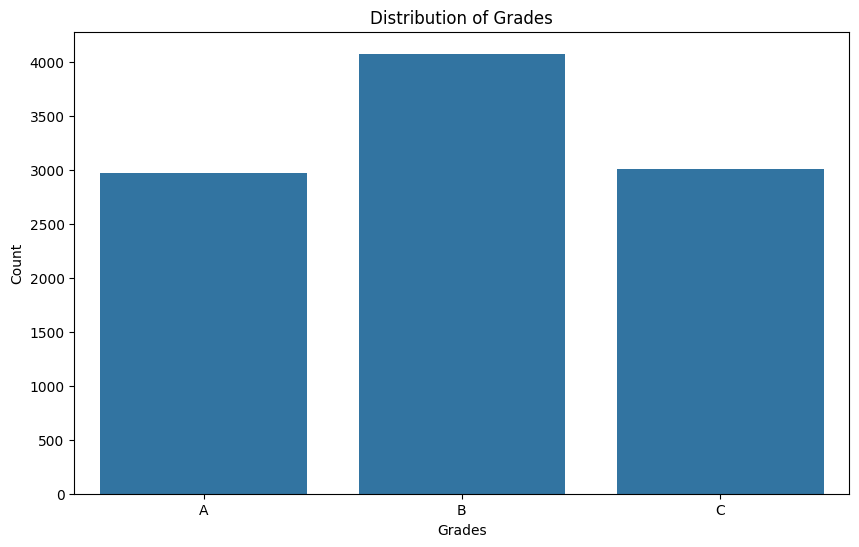

In [8]:
# Visualization 1: Distribution of Grades
grades_list = sorted(df['Grades'].unique())
plt.figure(figsize=(10, 6))
sns.countplot(x='Grades', data=df, order=grades_list)
plt.title('Distribution of Grades')
plt.xlabel('Grades')
plt.ylabel('Count')
plt.savefig("Distribution_of_Grades.png")
plt.show()

<Figure size 1500x600 with 0 Axes>

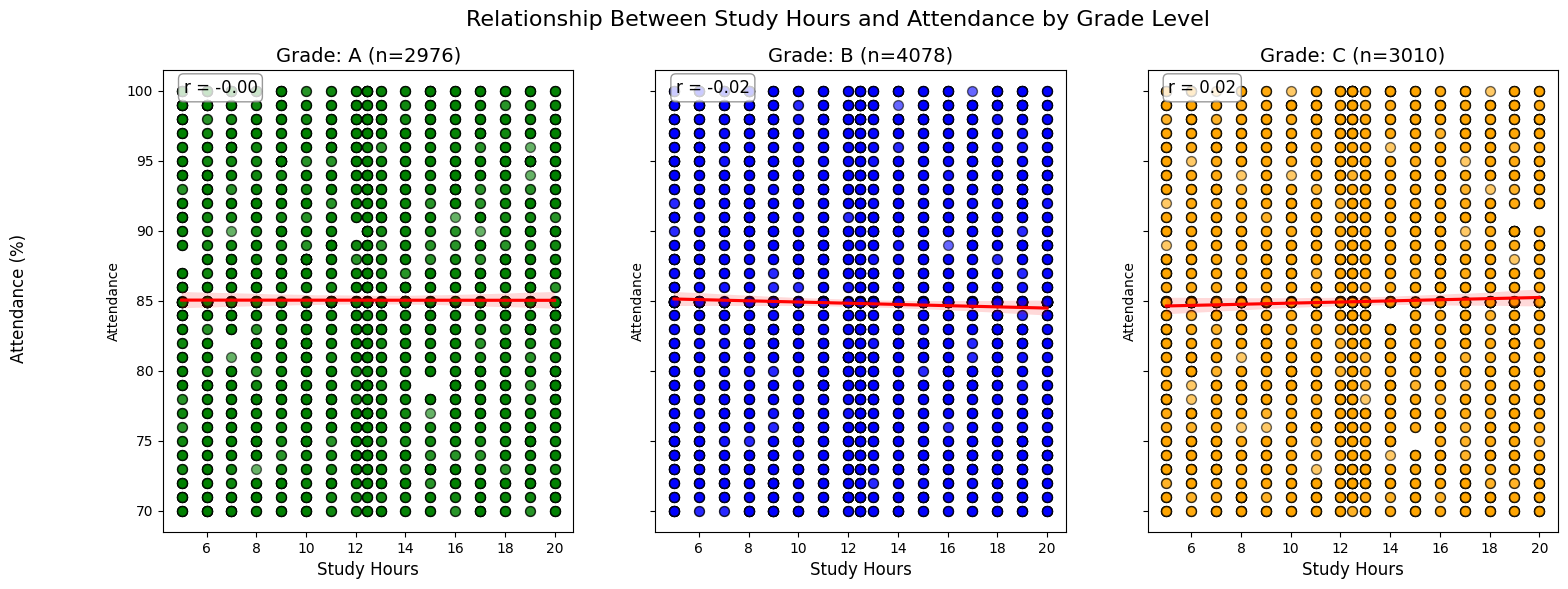

In [9]:
# Create a figure for the scatterplots
plt.figure(figsize=(15, 6))

# Create scatterplots for each grade
# Using subplots for side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)

# Define colors for better visualization
colors = {'A': 'green', 'B': 'blue', 'C': 'orange'}
grade_labels = ['A', 'B', 'C']

# Create a scatterplot for each grade
for i, grade in enumerate(grade_labels):
    grade_data = df[df["Grades"] == grade]
    
    # Check if data exists for this grade
    if len(grade_data) > 0:
        axes[i].scatter(
            grade_data['Study_Hours'], 
            grade_data['Attendance'],
            alpha=0.6, 
            color=colors.get(grade, 'gray'),
            edgecolor='k',
            s=50
        )
        
        # Add a trend line
        sns.regplot(
            x='Study_Hours', 
            y='Attendance', 
            data=grade_data,
            scatter=False,
            ax=axes[i], 
            color='red'
        )
        
        # Set titles and labels
        axes[i].set_title(f'Grade: {grade} (n={len(grade_data)})', fontsize=14)
        axes[i].set_xlabel('Study Hours', fontsize=12)
        
        # Add correlation coefficient
        corr = grade_data['Study_Hours'].corr(grade_data['Attendance'])
        axes[i].annotate(f'r = {corr:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', 
                        fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Set common y-label
fig.text(0.04, 0.5, 'Attendance (%)', va='center', rotation='vertical', fontsize=12)

# Add a main title
plt.suptitle('Relationship Between Study Hours and Attendance by Grade Level', fontsize=16)

# Display the plot
plt.show()

# Save the figure
#plt.savefig('attendance_vs_study_hours_by_grade.png', dpi=300, bbox_inches='tight')

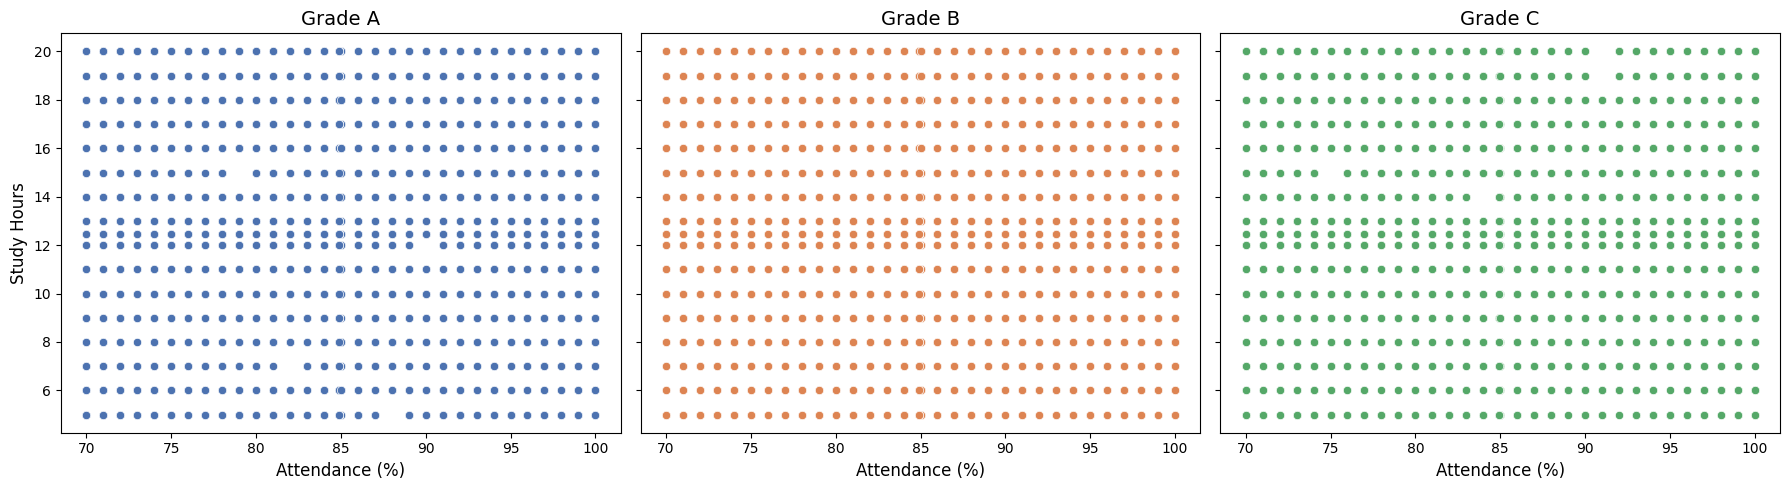

In [10]:
# Define unique grades to filter
grades = ['A', 'B', 'C']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Loop through each grade and create a scatter plot
for i, grade in enumerate(grades):
    subset = df[df['Grades'] == grade]
    sns.scatterplot(x='Attendance', y='Study_Hours', data=subset, ax=axes[i], color=sns.color_palette("deep")[i])
    axes[i].set_title(f'Grade {grade}', fontsize=14)
    axes[i].set_xlabel('Attendance (%)', fontsize=12)
    if i == 0:
        axes[i].set_ylabel('Study Hours', fontsize=12)
    else:
        axes[i].set_ylabel('')

# Adjust layout and display
plt.tight_layout()
plt.show()

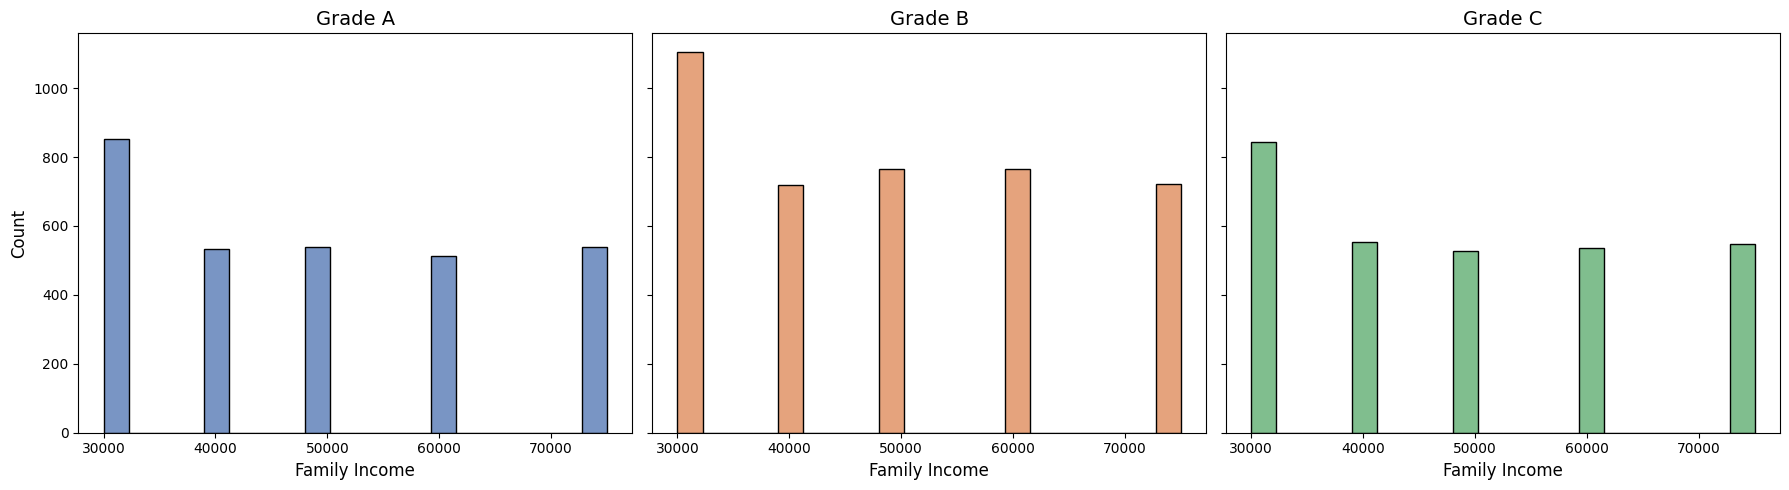

In [11]:
# Ensure 'Family_Income' is numeric, converting errors to NaN
df['Family_Income'] = pd.to_numeric(df['Family_Income'], errors='coerce')
df = df.dropna(subset=['Family_Income'])

# Define unique grades to filter
grades = ['A', 'B', 'C']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Loop through each grade and create a histogram for sorted Family_Income
for i, grade in enumerate(grades):
    subset = df[df['Grades'] == grade]
    sorted_income = subset['Family_Income'].sort_values()
    
    sns.histplot(sorted_income, bins=20, kde=False, ax=axes[i], color=sns.color_palette("deep")[i])
    axes[i].set_title(f'Grade {grade}', fontsize=14)
    axes[i].set_xlabel('Family Income', fontsize=12)
    if i == 0:
        axes[i].set_ylabel('Count', fontsize=12)
    else:
        axes[i].set_ylabel('')

# Adjust layout and display
plt.tight_layout()
plt.show()

C:\Users\max\AppData\Local\Temp\ipykernel_48124\1124074242.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mentoring_percent.index, y=mentoring_percent.values, ax=axes[i], palette="deep")
C:\Users\max\AppData\Local\Temp\ipykernel_48124\1124074242.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mentoring_percent.index, y=mentoring_percent.values, ax=axes[i], palette="deep")
C:\Users\max\AppData\Local\Temp\ipykernel_48124\1124074242.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mentoring_percent.index, y=mentoring_percen

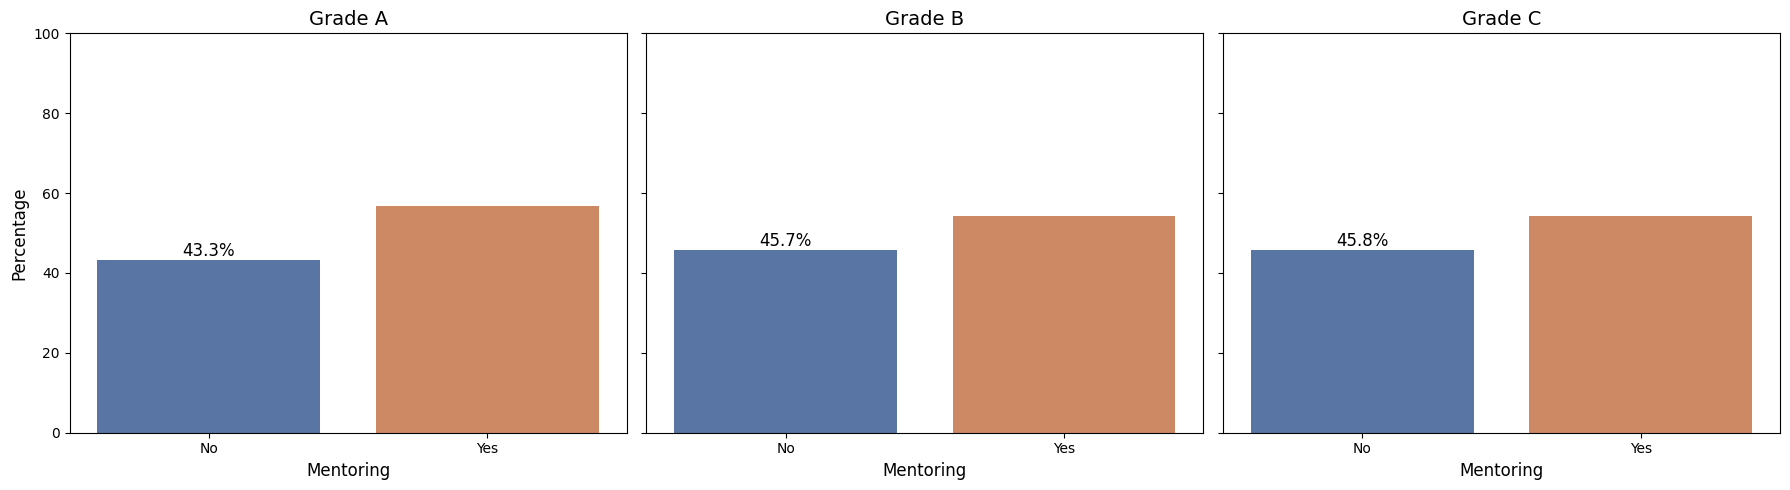

In [12]:
# Ensure the 'Mentoring' column exists and drop missing values
df = df.dropna(subset=['Grades', 'Mentoring'])

# Define unique grades to filter
grades = ['A', 'B', 'C']

# Set up the figure for subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Loop through each grade and create a percentage bar plot for Mentoring
for i, grade in enumerate(grades):
    subset = df[df['Grades'] == grade]

    # Calculate percentage distribution
    mentoring_counts = subset['Mentoring'].value_counts(normalize=True) * 100  # Convert to percentage
    mentoring_percent = mentoring_counts.reindex(['No', 'Yes'], fill_value=0)  # Ensure both categories are present

    # Create bar plot
    sns.barplot(x=mentoring_percent.index, y=mentoring_percent.values, ax=axes[i], palette="deep")
    axes[i].set_title(f'Grade {grade}', fontsize=14)
    axes[i].set_xlabel('Mentoring', fontsize=12)
    axes[i].set_ylabel('Percentage', fontsize=12)
    axes[i].set_ylim(0, 100)  # Set y-axis limit to 100%

    # Add percentage labels on bars
    for p, percentage in zip(axes[i].containers[0], mentoring_percent.values):
        axes[i].annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()), 
                         ha='center', va='bottom', fontsize=12)

# Adjust layout and display
#plt.savefig("mentoring_by_grade.png")
plt.tight_layout()
plt.show()

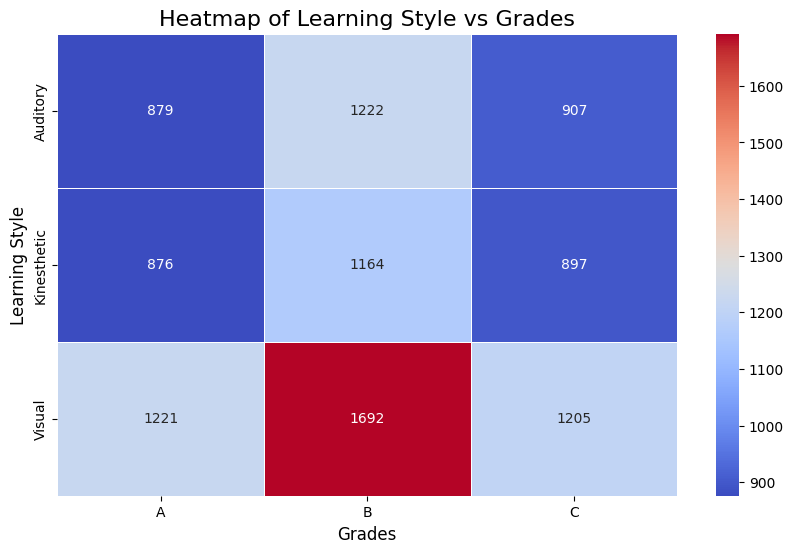

In [13]:
# Create a crosstab of Learning_Style vs Grades
cross_tab = pd.crosstab(df['Learning_Style'], df['Grades'])

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='coolwarm', linewidths=0.5)

# Add labels and title
plt.title('Heatmap of Learning Style vs Grades', fontsize=16)
plt.xlabel('Grades', fontsize=12)
plt.ylabel('Learning Style', fontsize=12)

# Show the plot
plt.savefig("grades_learning_style_heatmap.png")
plt.show()

In [14]:
# Aggregate data to get percentage of "Yes" for each factor by grade
summary_df = df.groupby("Grades").agg({
    "Mentoring": lambda x: (x == "Yes").mean() * 100,
    "Tutoring": lambda x: (x == "Yes").mean() * 100,
    "Educational_Resources": lambda x: (x == "Yes").mean() * 100,
    "Extracurricular_Activities": lambda x: (x == "Yes").mean() * 100,
}).reset_index()

# Melt the dataframe to have a long format for easy plotting
summary_df = summary_df.melt(id_vars="Grades", var_name="Factor", value_name="Percentage")

# Create an interactive grouped bar plot
fig = px.bar(summary_df, 
             x="Factor", 
             y="Percentage", 
             color="Grades", 
             barmode="group",  # Group bars side by side
             title="Impact of Factors on Grades",
             labels={"Percentage": "Percentage of Students (%)"},
             template="plotly_white",
             text=summary_df["Percentage"].round(1))  # Display values on bars

# Update layout for better readability
fig.update_traces(textposition='outside')  # Position text outside bars
fig.update_layout(
    xaxis_title="Factors",
    yaxis_title="Percentage of Students (%)",
    showlegend=True
)

# Save the chart as an interactive HTML file
fig.write_html("interactive_bar_chart.html")
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
'''
# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Screen_Time', y='Time_Wasted_on_Social_Media', hue='Grades', data=df, s=100)

# Add labels and title
plt.title('Scatterplot of Study Hours vs Attendance Colored by Grades')
plt.xlabel('Study Hours')
plt.ylabel('Attendance (%)')
plt.legend(title = 'Grades', bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()
'''

"\n# Create the scatterplot\nplt.figure(figsize=(10, 6))\nsns.scatterplot(x='Screen_Time', y='Time_Wasted_on_Social_Media', hue='Grades', data=df, s=100)\n\n# Add labels and title\nplt.title('Scatterplot of Study Hours vs Attendance Colored by Grades')\nplt.xlabel('Study Hours')\nplt.ylabel('Attendance (%)')\nplt.legend(title = 'Grades', bbox_to_anchor=(1.05, 1), loc='upper left')\n\n# Show the plot\nplt.show()\n"

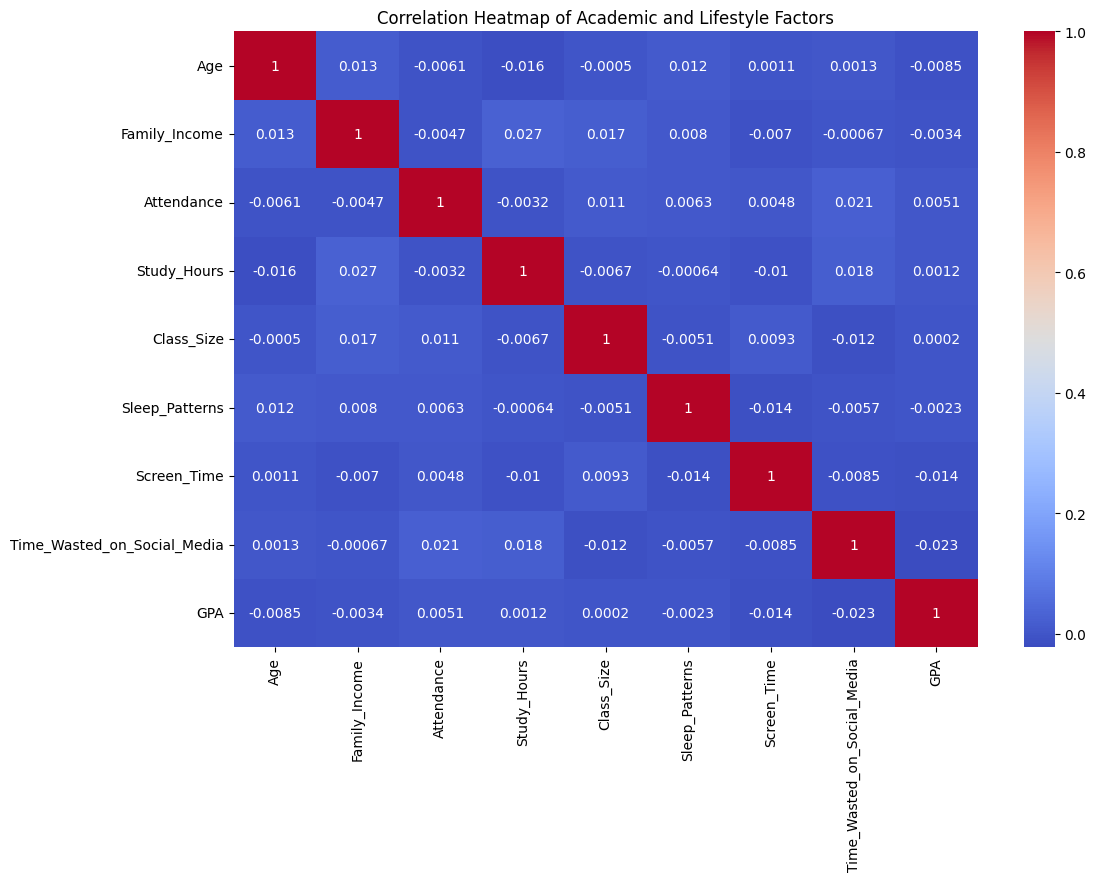

In [15]:
# Visualization 2: Correlation Heatmap
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Academic and Lifestyle Factors')

plt.savefig("correlation.png")
plt.show()

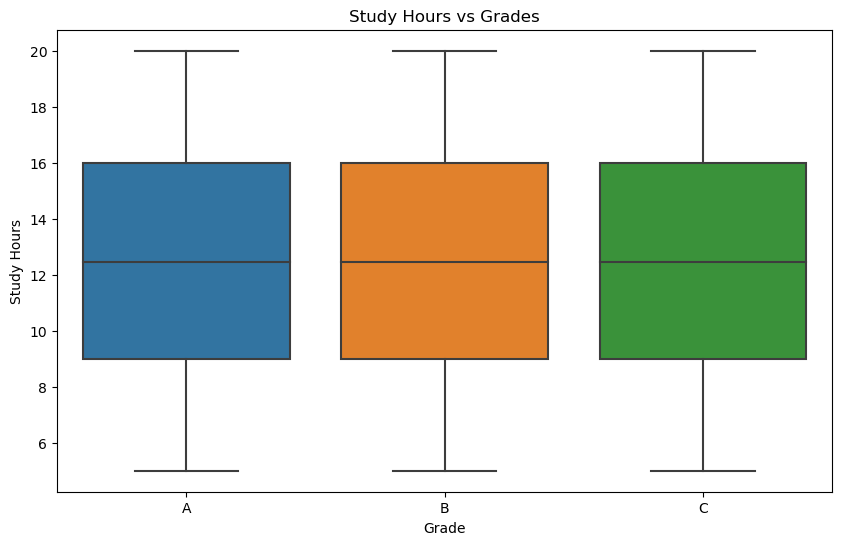

In [ ]:
# Visualization 3: Study Hours vs GPA
plt.figure(figsize=(10, 6))
sns.boxplot(x='Grades', y='Study_Hours', data=df, order=sorted(df['Grades'].unique()))
plt.title('Study Hours vs Grades')
plt.xlabel('Grade')
plt.ylabel('Study Hours')
plt.show()

In [ ]:
# Sample 5,000 rows from the dataset
df_sampled = df.sample(n=5000, random_state=8)

# Create an interactive box plot
box_plot = alt.Chart(df_sampled).mark_boxplot().encode(
    x='Gender:N',  
    y='GPA:Q',    
    #color='Parental_Education:N', 
    tooltip=['Gender', 'Parental_Education', 'GPA']  
).properties(
    title='Distribution of Student Grades by Demographic Groups',
    width=600,
    height=400
)

# Add interactivity (zoom and pan)
interactive_plot = box_plot.interactive()

# Show the plot
interactive_plot.show()

alt.Chart(...)

In [ ]:
fig = px.scatter(
    df,
    x='Study_Hours',
    y='GPA',
    color='Class_Participation',
    hover_data=['Major', 'Grades'],
    title='Study Hours vs GPA (Interactive by Major)'
)

# Save plot as HTML for iframe embedding
fig.write_html("plotly_chart.html")

In [ ]:
# Group by Sports_Participation and Grades, count occurrences
grouped_data = df.groupby(['Sports_Participation', 'Grades']).size().reset_index(name='count')

# Drop rows with missing values in either column
grouped_data.dropna(subset=['Sports_Participation', 'Grades'], inplace=True)

# Sort for consistency
grouped_data.sort_values(by=['Sports_Participation', 'Grades'], inplace=True)
grouped_data.to_csv("activity_grades.csv")